**Install & Authenticate Kaggle**

In [5]:
# Step 1.1: Install Kaggle
!pip install -q kaggle

# Step 1.2: Upload your Kaggle API token
# ⚠️ Go to: https://www.kaggle.com/settings/account → Scroll to "API" → Click "Create New API Token"
# It will download a file named: kaggle.json

# Now run this cell → it will prompt you to upload kaggle.json
from google.colab import files
files.upload()  # 👈 Upload the kaggle.json file here

# Step 1.3: Move it to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle (1).json to kaggle (1).json


**Download & Extract Dataset**

In [6]:
# Step 2.1: Download dataset from Kaggle
!kaggle datasets download -d abdulmumeet/dataset-on-eye-disease-with-smote

# Step 2.2: Unzip it
!unzip -q dataset-on-eye-disease-with-smote.zip -d eye_disease_dataset

# Step 2.3: Check folder structure
!ls eye_disease_dataset

Dataset URL: https://www.kaggle.com/datasets/abdulmumeet/dataset-on-eye-disease-with-smote
License(s): unknown
  0% 0.00/40.8M [00:00<?, ?B/s]
100% 40.8M/40.8M [00:00<00:00, 1.69GB/s]
'Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation'


**Set Dataset Path & Parameters**

In [15]:
import os

# Rename the folder to a simple name
!mv "eye_disease_dataset/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation" eye_disease_dataset/eye_disease_images

# Set new path
DATASET_PATH = "eye_disease_dataset/eye_disease_images"

# Confirm classes
print("Available classes:")
for folder in sorted(os.listdir(DATASET_PATH)):
    if os.path.isdir(os.path.join(DATASET_PATH, folder)):
        count = len(os.listdir(os.path.join(DATASET_PATH, folder)))
        print(f"  - {folder}: {count} images")

Available classes:
  - Cataract: 544 images
  - Conjunctivitis: 357 images
  - Eyelid: 525 images
  - Normal: 649 images
  - Uveitis: 223 images


**Create Proper Train/Val Directories**

In [21]:
import os
import shutil
import random
from pathlib import Path

# Paths
SOURCE_DIR = "eye_disease_dataset/eye_disease_images"
BASE_DIR = "eye_dataset_split"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

# Create directories
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

# For each class, split 80% train, 20% val
for class_name in os.listdir(SOURCE_DIR):
    src_class_path = os.path.join(SOURCE_DIR, class_name)
    if not os.path.isdir(src_class_path):
        continue

    # Create class folders in train/val
    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, class_name), exist_ok=True)

    # Get all image paths
    all_images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(all_images)

    # Split 80/20
    split_idx = int(0.8 * len(all_images))
    train_images = all_images[:split_idx]
    val_images = all_images[split_idx:]

    # Copy to train
    for img in train_images:
        shutil.copy(
            os.path.join(src_class_path, img),
            os.path.join(TRAIN_DIR, class_name, img)
        )

    # Copy to val
    for img in val_images:
        shutil.copy(
            os.path.join(src_class_path, img),
            os.path.join(VAL_DIR, class_name, img)
        )

    print(f"{class_name}: {len(train_images)} train, {len(val_images)} val")

Uveitis: 178 train, 45 val
Cataract: 435 train, 109 val
Normal: 519 train, 130 val
Eyelid: 420 train, 105 val
Conjunctivitis: 285 train, 72 val


**Compute Class Weights (Handle Imbalance)**

In [22]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_names = sorted(os.listdir(TRAIN_DIR))
# Count training samples per class
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in class_names]
labels = np.concatenate([[i] * count for i, count in enumerate(train_counts)])

class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))

print("\nClass Weights:")
for i, w in enumerate(class_weights):
    print(f"  {class_names[i]}: {w:.4f}")


Class Weights:
  Cataract: 0.8446
  Conjunctivitis: 1.2891
  Eyelid: 0.8748
  Normal: 0.7079
  Uveitis: 2.0640


**Prepare Data Generators (No Aug on Validation!)**

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)  # MobileNetV2 input size
BATCH_SIZE = 32

# ✅ ONLY train gets augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # ❌ No augmentation on val

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1837 images belonging to 5 classes.
Found 461 images belonging to 5 classes.


**Build MobileNetV2 Model**

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

# ✅ Use higher learning rate
model.compile(
    optimizer=Adam(learning_rate=0.001),  # 1e-3 (not 1e-5!)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Setup Callbacks (Early Stop + LR Reduce)**

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenet_eye.keras', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

**Train the Model**

In [26]:
print("🚀 Training MobileNetV2 with proper split...")
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Critical!
    verbose=1
)

🚀 Training MobileNetV2 with proper split...
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.5257 - loss: 1.4604
Epoch 1: val_loss improved from inf to 0.56826, saving model to best_mobilenet_eye.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 64s 762ms/step - accuracy: 0.5279 - loss: 1.4533 - val_accuracy: 0.7918 - val_loss: 0.5683 - learning_rate: 0.0010
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7785 - loss: 0.6966
Epoch 2: val_loss improved from 0.56826 to 0.51128, saving model to best_mobilenet_eye.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 446ms/step - accuracy: 0.7786 - loss: 0.6962 - val_accuracy: 0.7983 - val_loss: 0.5113 - learning_rate: 0.0010
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7986 - loss: 0.5958
Epoch 3: val_loss improved from 0.51128 to 0.39222, saving model to best_mobilenet_eye.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 399ms/step - accuracy: 0.7988 - loss: 0.5955 - val_accuracy: 0.8720 - val_loss: 0.3922 - learning_rate: 0.00

In [40]:
import os

train_path = "eye_dataset_split/train"
val_path = "eye_dataset_split/val"

print("Train classes:", os.listdir(train_path))
print("Val classes:", os.listdir(val_path))
print("Train class count:", len(os.listdir(train_path)))
print("Val class count:", len(os.listdir(val_path)))

Train classes: ['Uveitis', 'Cataract', 'Normal', 'Eyelid', 'Conjunctivitis']
Val classes: ['Uveitis', 'Cataract', 'Normal', 'Eyelid', 'Conjunctivitis']
Train class count: 5
Val class count: 5


15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 382ms/step


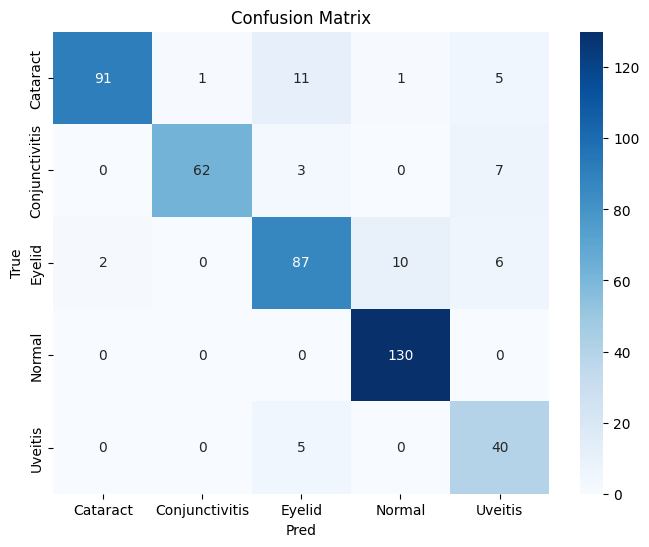


📊 Detailed Report:
                precision    recall  f1-score   support

      Cataract       0.98      0.83      0.90       109
Conjunctivitis       0.98      0.86      0.92        72
        Eyelid       0.82      0.83      0.82       105
        Normal       0.92      1.00      0.96       130
       Uveitis       0.69      0.89      0.78        45

      accuracy                           0.89       461
     macro avg       0.88      0.88      0.88       461
  weighted avg       0.90      0.89      0.89       461



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
val_gen.reset()
y_true = val_gen.classes
y_pred = model.predict(val_gen)
y_pred_classes = y_pred.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(val_gen.class_indices.keys())

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Pred')
plt.show()

# Classification Report
print("\n📊 Detailed Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [33]:
import json

# Save class indices to a JSON file
class_indices = train_gen.class_indices  # e.g., {'Cataract': 0, 'Conjunctivitis': 1, ...}
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

# Download it
from google.colab import files
files.download('class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# Instead of just model.save(), use this:
model.save('best_mobilenet_eye.keras', save_format='keras')

**Evaluate**

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8525 - loss: 0.3646

✅ Final Validation Accuracy: 0.8894 (88.94%)


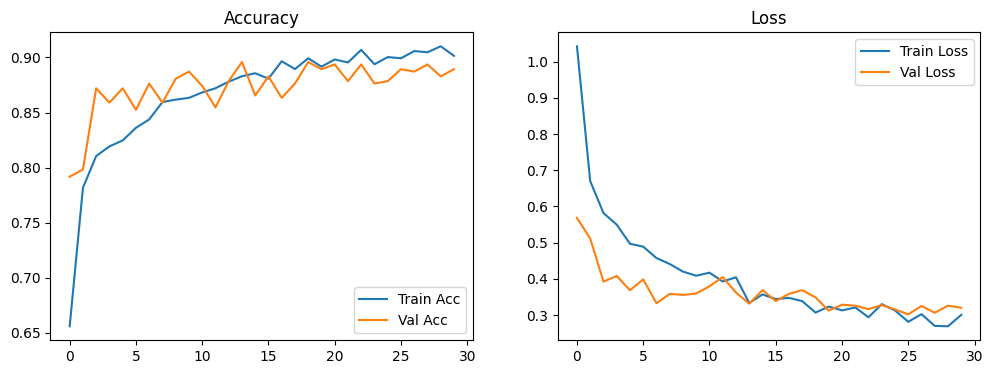

In [31]:
# Final accuracy
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n✅ Final Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend()
plt.show()

In [29]:
from google.colab import files
files.download('best_mobilenet_eye.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# Save ONLY weights (more compatible)
model.save_weights('best_mobilenet_eye.weights.h5')

# Download weights
from google.colab import files
files.download('best_mobilenet_eye.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import cv2
import os
import numpy as np

def blur_score(img_path):
    img = cv2.imread(img_path, 0)
    return cv2.Laplacian(img, cv2.CV_64F).var()

# Test 5 Normal images
normal_dir = "eye_dataset_split/train/Normal"
scores = []
for img_name in os.listdir(normal_dir)[:10]:
    score = blur_score(os.path.join(normal_dir, img_name))
    scores.append(score)
    print(f"{img_name}: {score:.2f}")

print("\nAverage blur (higher = sharper):", np.mean(scores))

581.jpg: 344.23
132.jpg: 780.12
233.jpg: 315.39
502.jpg: 1192.03
166.jpg: 777.34
276.jpg: 2212.60
206.jpg: 1478.79
513.jpg: 1113.15
402.jpg: 1834.95
315.jpg: 1589.22

Average blur (higher = sharper): 1163.7822257689459


In [36]:
# Get all Normal image predictions
normal_dir = "eye_dataset_split/val/Normal"
normal_true, normal_pred = [], []

for img_name in os.listdir(normal_dir):
    img_path = os.path.join(normal_dir, img_name)
    img = tf.keras.utils.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred[0])

    normal_true.append(3)  # Normal class index
    normal_pred.append(pred_class)

# Count misclassifications
import collections
misclassified = [CLASS_NAMES[i] for i in normal_pred if i != 3]
print("Normal images misclassified as:")
print(collections.Counter(misclassified))

Normal images misclassified as:
Counter()


In [38]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

# Get class names from training generator (critical!)
CLASS_NAMES = list(train_gen.class_indices.keys())
print("Model trained on classes:", CLASS_NAMES)

# Pick a Normal image from validation set
normal_img_path = "eye_dataset_split/val/Normal/" + os.listdir("eye_dataset_split/val/Normal/")[0]
print("\nTesting image:", normal_img_path)

# Load and preprocess
img = image.load_img(normal_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
pred = model.predict(img_array, verbose=0)
predicted_idx = np.argmax(pred[0])
confidence = pred[0][predicted_idx]

# Show result
print(f"\n✅ Prediction: {CLASS_NAMES[predicted_idx]} ({confidence:.2%})")

Model trained on classes: ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']

Testing image: eye_dataset_split/val/Normal/683.jpg

✅ Prediction: Normal (100.00%)
